# Lib


In [102]:
from itertools import combinations

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

# Data preparation


In [103]:
df_edges = pd.read_csv("../../data/github_social_network/musae_git_edges.csv")

df_edges.columns = df_edges.columns.str.strip().str.lower().str.replace(" ", "_")

print(df_edges.shape)

(289003, 2)


In [104]:
df_edges.head()

,id_1,id_2
0,0,23977
1,1,34526
2,1,2370
3,1,14683
4,1,29982


# Graph


In [105]:
G = nx.from_pandas_edgelist(
    df_edges, source="id_1", target="id_2", create_using=nx.Graph()
)

In [106]:
nx.describe(G)

Number of nodes                : 37700
Number of edges                : 289003
Directed                       : False
Multigraph                     : False
Tree                           : False
Bipartite                      : False
Average degree (min, max)      : 15.33 (1, 9458)
Number of connected components : 1


In [107]:
# Convert edges to sorted tuples
all_edges = [tuple(sorted((u, v))) for u, v in G.edges()]

# Remove duplicates while preserving order
all_edges = list(dict.fromkeys(all_edges))

rng = np.random.default_rng(42)

print(f"Total unique edges: {len(all_edges):,}")

Total unique edges: 289,003


# Sampling


## Positive Edge Sampling

The true edges of the graph are split into two subsets:
- Train Positive Edges
- Test Positive Edges

Note:
- Avoid assigning `bridge edges` to the test set.
- A **bridge edge** is an edge whose removal increases the number of connected components in the graph.

In [108]:
def sample_positive_edges(
    edges: list[tuple[int, int]],
    test_ratio: float,
    graph: nx.Graph,
    random_state: int,
) -> tuple[
    list[tuple[int, int]],
    list[tuple[int, int]],
    set[tuple[int, int]],
]:

    rng_local = np.random.default_rng(random_state)

    n_test = int(len(edges) * test_ratio)

    # Find bridge edges
    bridge_edges = {tuple(sorted(edge)) for edge in nx.bridges(graph)}

    # Prefer non-bridge edges for test
    non_bridge_edges = [edge for edge in edges if edge not in bridge_edges]

    if len(non_bridge_edges) >= n_test:

        test_indices = rng_local.choice(
            len(non_bridge_edges),
            size=n_test,
            replace=False,
        )

        test_pos = [non_bridge_edges[index] for index in test_indices]

    else:
        test_pos = list(non_bridge_edges)

        remaining = n_test - len(test_pos)

        bridge_pool = [edge for edge in edges if edge in bridge_edges]

        if remaining > len(bridge_pool):
            raise ValueError(
                "Not enough positive edges to create the requested test split."
            )

        bridge_indices = rng_local.choice(
            len(bridge_pool),
            size=remaining,
            replace=False,
        )

        test_pos.extend([bridge_pool[index] for index in bridge_indices])

    test_pos = [tuple(edge) for edge in test_pos]

    test_set = set(test_pos)

    train_pos = [edge for edge in edges if edge not in test_set]

    return train_pos, test_pos, bridge_edges

## Hard Negative Sampling

Hard Negative Definition: 
- A **hard negative** is a node pair $(A, B)$ that does **not** have a direct connection.
- They share at least one common neighbor.

Example: Consider the following structure: `A --- C --- B`

In [109]:
def sample_hard_negative_pairs(
    graph: nx.Graph,
    n_samples: int,
    forbidden_pairs: set[tuple[int, int]],
    random_state: int,
) -> list[tuple[int, int]]:

    rng_local = np.random.default_rng(random_state)

    nodes = list(graph.nodes())

    rng_local.shuffle(nodes)

    sampled_pairs = []
    sampled_set = set()

    for mid_node in nodes:

        neighbors = list(graph.neighbors(mid_node))

        if len(neighbors) < 2:
            continue

        rng_local.shuffle(neighbors)

        for left_index in range(len(neighbors) - 1):

            for right_index in range(
                left_index + 1,
                len(neighbors),
            ):

                u = neighbors[left_index]
                v = neighbors[right_index]

                pair = tuple(sorted((u, v)))

                if (
                    pair in forbidden_pairs
                    or pair in sampled_set
                    or graph.has_edge(u, v)
                ):
                    continue

                sampled_set.add(pair)
                sampled_pairs.append(pair)

                if len(sampled_pairs) == n_samples:
                    return sampled_pairs

    raise ValueError("Not enough hard-negative candidates with a shared neighbor.")

# Splitting


## Train/test samples


In [110]:
train_pos, test_pos, bridge_edges = sample_positive_edges(
    edges=all_edges,
    test_ratio=0.2,
    graph=G,
    random_state=42,
)

print(f"Train positive edges: {len(train_pos):,}")
print(f"Test positive edges: {len(test_pos):,}")

Train positive edges: 231,203
Test positive edges: 57,800


## Negative samples


In [111]:
positive_forbidden = set(all_edges)

train_neg = sample_hard_negative_pairs(
    graph=G,
    n_samples=len(train_pos),
    forbidden_pairs=positive_forbidden,
    random_state=42,
 )

negative_forbidden = positive_forbidden.union(train_neg)

test_neg = sample_hard_negative_pairs(
    graph=G,
    n_samples=len(test_pos),
    forbidden_pairs=negative_forbidden,
    random_state=42,
 )

train_neg_set = set(train_neg)
test_neg_set = set(test_neg)

assert train_neg_set.isdisjoint(positive_forbidden)
assert test_neg_set.isdisjoint(positive_forbidden)
assert train_neg_set.isdisjoint(test_neg_set)

In [112]:
print(f"Train negative edges: {len(train_neg):,}")
print(f"Test negative edges: {len(test_neg):,}")

Train negative edges: 231,203
Test negative edges: 57,800


# Link Prediction Dataset

Dataset gồm:

- source
- target
- label
  - 1 = positive edge
  - 0 = negative edge
- split
  - train/test
- type
  - positive/negative


In [113]:
train_df = pd.DataFrame(
    {
        "source": [u for u, _ in train_pos + train_neg],
        "target": [v for _, v in train_pos + train_neg],
        "label": [1] * len(train_pos) + [0] * len(train_neg),
        "split": ["train"] * (len(train_pos) + len(train_neg)),
        "type": (["positive"] * len(train_pos) + ["negative"] * len(train_neg)),
    }
)

test_df = pd.DataFrame(
    {
        "source": [u for u, _ in test_pos + test_neg],
        "target": [v for _, v in test_pos + test_neg],
        "label": [1] * len(test_pos) + [0] * len(test_neg),
        "split": ["test"] * (len(test_pos) + len(test_neg)),
        "type": (["positive"] * len(test_pos) + ["negative"] * len(test_neg)),
    }
)

In [114]:
link_prediction_df = pd.concat(
    [train_df, test_df],
    ignore_index=True,
)
link_prediction_df.head()

,source,target,label,split,type
0,0,23977,1,train,positive
1,69,23977,1,train,positive
2,1966,23977,1,train,positive
3,4422,23977,1,train,positive
4,5631,23977,1,train,positive


# Distribution


In [115]:
label_distribution = (
    link_prediction_df.groupby(["split", "label"]).size().reset_index(name="count")
)

label_distribution["percentage"] = (
    label_distribution["count"]
    / label_distribution.groupby("split")["count"].transform("sum")
    * 100
).round(2)

display(label_distribution)

,split,label,count,percentage
0,test,0,57800,50.0
1,test,1,57800,50.0
2,train,0,231203,50.0
3,train,1,231203,50.0


## Percentage


In [116]:
print(f"Total edges in graph: {len(all_edges):,}")
print(f"Bridge edges protected in train: {len(bridge_edges):,}")

print(f"Train positive: {len(train_pos):,}")
print(f"Train negative: {len(train_neg):,}")

print(f"Test positive: {len(test_pos):,}")
print(f"Test negative: {len(test_neg):,}")

Total edges in graph: 289,003
Bridge edges protected in train: 5,241
Train positive: 231,203
Train negative: 231,203
Test positive: 57,800
Test negative: 57,800


In [117]:
link_prediction_df.groupby(["split", "type"]).size().unstack()

type,negative,positive
split,,
test,57800,57800
train,231203,231203


## Visualization


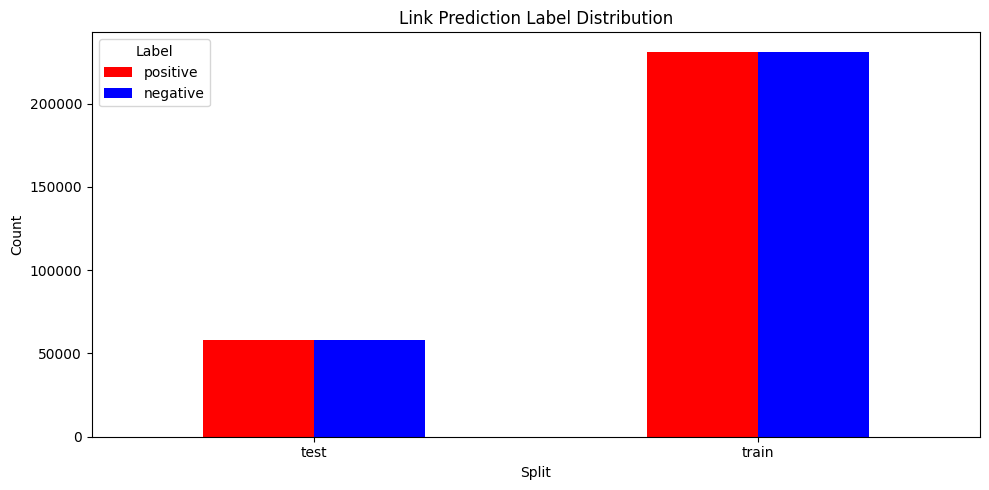

In [118]:
pivot_distribution = label_distribution.pivot(
    index="split",
    columns="label",
    values="count",
).fillna(0)

pivot_distribution.columns = [
    "negative",
    "positive",
]

pivot_distribution = pivot_distribution[["positive", "negative"]]

ax = pivot_distribution.plot(
    kind="bar",
    figsize=(10, 5),
    color=["red", "blue"],
    rot=0,
)

ax.set_title("Link Prediction Label Distribution")

ax.set_xlabel("Split")
ax.set_ylabel("Count")

ax.legend(title="Label")

plt.tight_layout()
plt.show()

# Conclusion


In [119]:
link_prediction_df.shape

(578006, 5)

In [120]:
positive_pairs = set(
    zip(
        link_prediction_df.loc[link_prediction_df["label"] == 1, "source"],
        link_prediction_df.loc[link_prediction_df["label"] == 1, "target"],
    )
)

negative_pairs = set(
    zip(
        link_prediction_df.loc[link_prediction_df["label"] == 0, "source"],
        link_prediction_df.loc[link_prediction_df["label"] == 0, "target"],
    )
)

overlap_pairs = positive_pairs.intersection(negative_pairs)

In [121]:
print(f"Positive pairs: {len(positive_pairs):,}")
print(f"Negative pairs: {len(negative_pairs):,}")
print(f"Overlap pairs: {len(overlap_pairs):,}")

Positive pairs: 289,003
Negative pairs: 289,003
Overlap pairs: 0


# Export


In [123]:
link_prediction_df.to_csv("../../data/processed/processed.csv", index=False)